# K-Means: Sistema de agrupación de casas
Queremos ser capaces de clasificar casas según su la región en la que se encuentren y del ingreso medio. Para ello, utilizaremos el famoso conjunto de datos California Housing. Se construyó utilizando los datos del censo de California de 1990. Contiene una fila por grupo de bloques censales. Un grupo de bloques es la unidad geográfica más pequeña para la que se publican datos del censo de USA.

## Paso 1: Cargar el conjunto de datos
El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre housing.csv. Puedes cargarlo en el código directamente desde el siguiente enlace:  
https://raw.githubusercontent.com/4GeeksAcademy/k-means-project-tutorial/main/housing.csv  
O descargarlo y añadirlo a mano en tu repositorio. 

In [7]:
import pandas as pd

total_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/k-means-project-tutorial/main/housing.csv")

total_data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3,41.0,7.0,1.0,322.0,2.6,37.9,-122.2,4.5
1,8.3,21.0,6.2,1.0,"2,401.0",2.1,37.9,-122.2,3.6
2,7.3,52.0,8.3,1.1,496.0,2.8,37.9,-122.2,3.5
3,5.6,52.0,5.8,1.1,558.0,2.5,37.9,-122.2,3.4
4,3.8,52.0,6.3,1.1,565.0,2.2,37.9,-122.2,3.4


### Eliminación de variables inútiles
En este caso solo nos interesan las columnas Latitude, Longitude y MedInc.

In [8]:
X = total_data[["MedInc", "Latitude", "Longitude"]]
X.head()

,MedInc,Latitude,Longitude
0,8.3,37.9,-122.2
1,8.3,37.9,-122.2
2,7.3,37.9,-122.2
3,5.6,37.9,-122.2
4,3.8,37.9,-122.2


### Dividir el conjunto de datos en entrenamiento y prueba

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en lecciones anteriores.  

Aunque estos conjuntos no se utilicen para obtener estadísticas, podrás utilizarlos para entrenar el algoritmo no supervisado y luego para hacer predicciones sobre puntos nuevos para predecir el cluster al que se asocian.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X, test_size = 0.2, random_state = 42)

X_train.head()

,MedInc,Latitude,Longitude
14196,3.3,32.7,-117.0
8267,3.8,33.8,-118.2
17445,4.2,34.7,-120.5
14265,1.9,32.7,-117.1
2271,3.6,36.8,-119.8


## Paso 2: Construir un K-Means

Clasifica los datos en 6 clusters utilizando, para ello, el modelo K-Means.  

In [10]:
from sklearn.cluster import KMeans

model_unsup = KMeans(n_clusters = 6, n_init = "auto", random_state = 42)
model_unsup.fit(X_train)

KMeans(n_clusters=6, random_state=42)

### Insertar clusters en el conjunto de datos de entrenamiento
Almacena el cluster al que pertenece cada casa como una columna nueva del dataset.  
Podrías llamarla cluster.   
Para introducirla a tu conjunto de datos quizá tengas que categorizarla.

Observa qué formato y valores tiene y actúa en consecuencia. 

In [11]:
y_train = list(model_unsup.labels_)
X_train["cluster"] = y_train
X_train.head()

,MedInc,Latitude,Longitude,cluster
14196,3.3,32.7,-117.0,3
8267,3.8,33.8,-118.2,1
17445,4.2,34.7,-120.5,1
14265,1.9,32.7,-117.1,3
2271,3.6,36.8,-119.8,5


### Trazado de resultados
La Grafícamos en un diagrama de puntos y describimos lo que se ve.

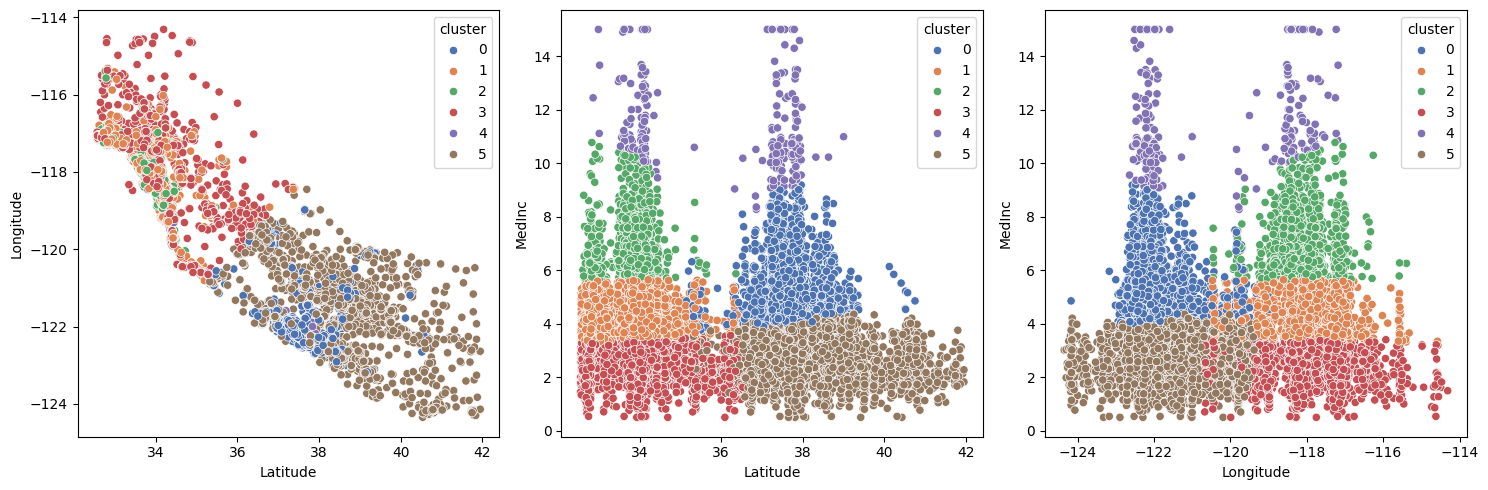

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(1, 3, figsize = (15, 5))

sns.scatterplot(ax = axis[0], data = X_train, x = "Latitude", y = "Longitude", hue = "cluster", palette = "deep")
sns.scatterplot(ax = axis[1], data = X_train, x = "Latitude", y = "MedInc", hue = "cluster", palette = "deep")
sns.scatterplot(ax = axis[2], data = X_train, x = "Longitude", y = "MedInc", hue = "cluster", palette = "deep")
plt.tight_layout()

plt.show()

## Paso 3: Predecir con el conjunto de pruebas
Ahora utiliza el modelo entrenado con el conjunto test y añade los puntos al gráfico anterior para confirmar que la predicción es satisfactoria o no.

In [13]:
y_test = list(model_unsup.predict(X_test))
X_test["cluster"] = y_test
X_test.head()

,MedInc,Latitude,Longitude,cluster
20046,1.7,36.1,-119.0,3
3024,2.5,35.1,-119.5,3
15663,3.5,37.8,-122.4,5
20484,5.7,34.3,-118.7,2
9814,3.7,36.6,-121.9,5


### Trazado de los resultados de las pruebas sobre la figura anterior

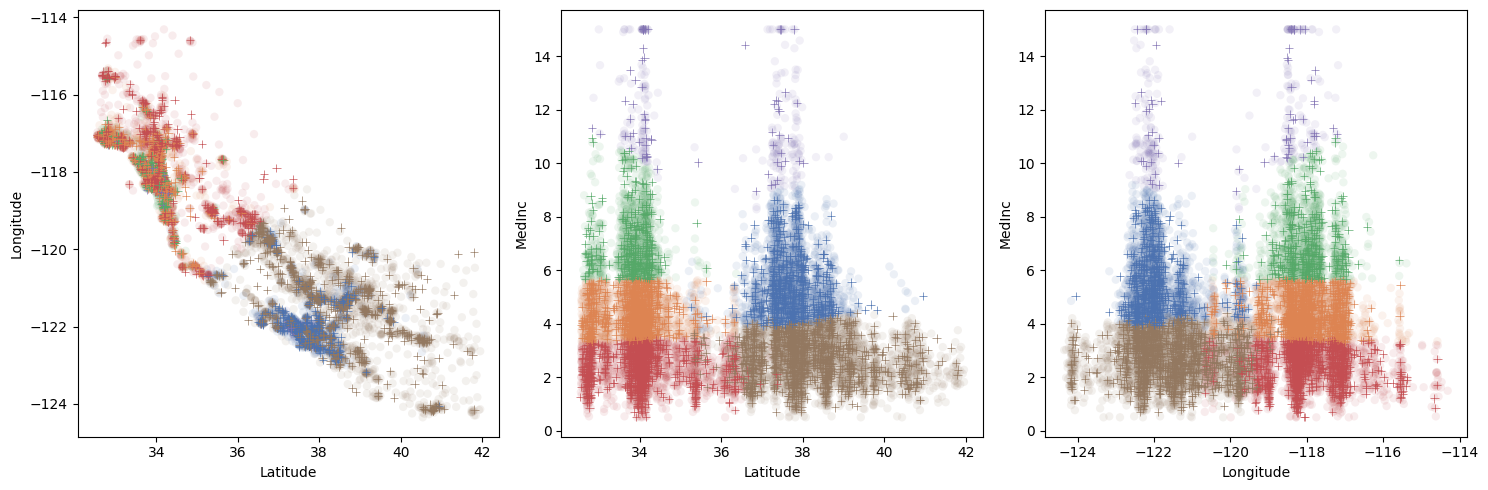

In [14]:
fig, axis = plt.subplots(1, 3, figsize = (15, 5))

sns.scatterplot(ax = axis[0], data = X_train, x = "Latitude", y = "Longitude", hue = "cluster", palette = "deep", alpha  = 0.1)
sns.scatterplot(ax = axis[1], data = X_train, x = "Latitude", y = "MedInc", hue = "cluster", palette = "deep", alpha  = 0.1)
sns.scatterplot(ax = axis[2], data = X_train, x = "Longitude", y = "MedInc", hue = "cluster", palette = "deep", alpha  = 0.1)

sns.scatterplot(ax = axis[0], data = X_test, x = "Latitude", y = "Longitude", hue = "cluster", palette = "deep", marker = "+")
sns.scatterplot(ax = axis[1], data = X_test, x = "Latitude", y = "MedInc", hue = "cluster", palette = "deep", marker = "+")
sns.scatterplot(ax = axis[2], data = X_test, x = "Longitude", y = "MedInc", hue = "cluster", palette = "deep", marker = "+")

plt.tight_layout()

for ax in axis:
    ax.legend([],[], frameon=False)

plt.show()

Como vemos, hay una gran fiabilidad a la hora de predecir a qué clúster pertenece cada punto de prueba.

## Paso 4: Entrenar un modelo de clasificación supervisado

Ahora que el K-Means nos ha devuelto una categorización (agrupación) de los puntos para los conjuntos de entrenamiento y prueba, estudia qué modelo podría ser más útil y entrénalo. Obtén las estadísticas y describe lo que ves.

Este flujo es muy común cuando contamos con datos no etiquetados: utilizar un modelo de aprendizaje no supervisado para etiquetarlos de forma automática y a continuación, un modelo de aprendizaje supervisado.

He elegido un Árbol de Decisión porque es una alternativa muy buena cuando queremos categorizar elementos según sus características intrínsecas, y no existe una relación lineal clara entre algunas variables. Además, no es necesario normalizar los valores.

In [15]:
from sklearn.tree import DecisionTreeClassifier

model_sup = DecisionTreeClassifier(random_state = 42)
model_sup.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

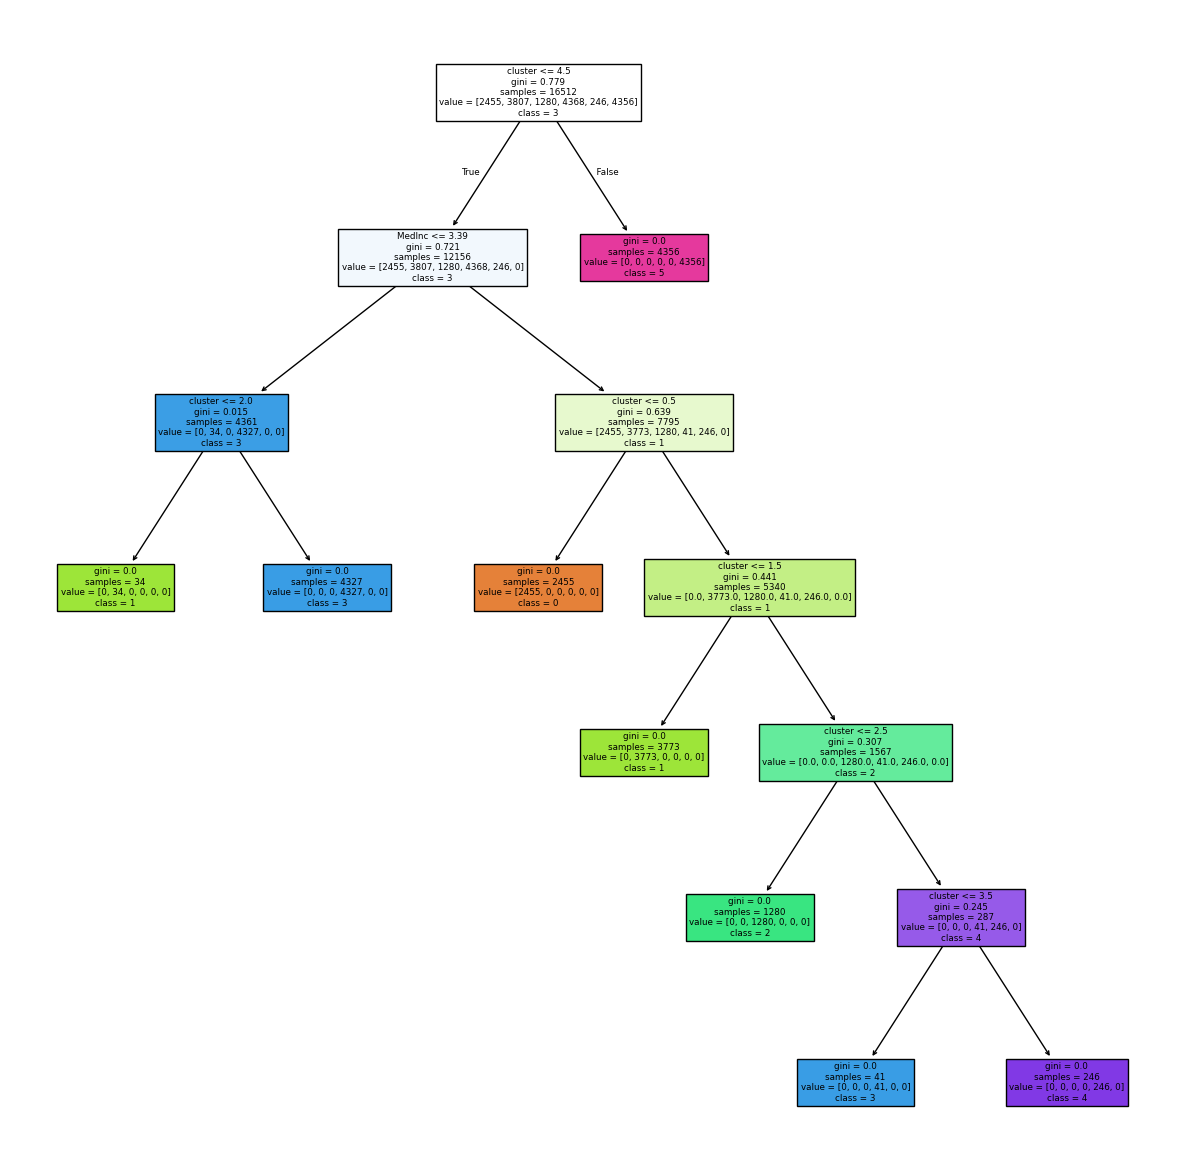

In [16]:
from sklearn import tree

fig = plt.figure(figsize=(15,15))

tree.plot_tree(model_sup, feature_names = list(X_train.columns), class_names = ["0", "1", "2", "3", "4", "5"], filled = True)

plt.show()

In [17]:
y_pred = model_sup.predict(X_test)
y_pred

array([3, 3, 5, ..., 4, 5, 1], shape=(4128,), dtype=int32)

In [18]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

1.0

## Paso 5: Guardar los modelos
Almacena ambos modelos en la carpeta correspondiente.



In [21]:
from pickle import dump

dump(model_unsup, open("./models/k-means_default_42.sav", "wb"))
dump(model_sup, open("./models/decision_tree_classifier_default_42.sav", "wb"))